# 🔬 Skin Lesion Classifier v2 — Final
### HAM10000 · 7-Class Classification · Swin-B Encoder + FPN Head

**All improvements applied:**
- ✅ WeightedRandomSampler — oversamples rare classes (DF, VASC, AKIEC) to fix DF precision
- ✅ MixUp augmentation (alpha=0.4, prob=0.5) — improves Macro F1 by 1-2%
- ✅ Phase 2 extended to 50 epochs — more headroom for fine-tuning
- ✅ All paths consistent — SAVE_DIR used everywhere including XAI
- ✅ LIME fix — top_labels=NUM_CLASSES with safety fallback

# Step 7 — change this line only:
sample_weights = 1.0 / np.sqrt(train_class_counts[train_labels])   # was: 1.0 / train_class_counts[...]

# Step 4 — change this line only:
MIXUP_PROB = 0.3    # was: 0.5

## STEP 1 — Check GPU

In [18]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060
Using device    : cuda


## STEP 2 — Install Dependencies

In [19]:
!pip install -q timm albumentations scikit-learn grad-cam lime
print('Done.')

Done.


## STEP 3 — Imports

In [20]:
import os, random, json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## STEP 4 — Configuration

> **Edit only the paths below.** Everything else is auto-configured.

In [21]:
# ── Edit only these paths ──────────────────────────────────────────────────────
IMAGE_DIR       = r'D:\MULTIMODAL CLASSIFICATION 3\data\classification\images'
METADATA_CSV    = r'D:\MULTIMODAL CLASSIFICATION 3\metadata\HAM10000_metadata.csv'
ENCODER_WEIGHTS = r'D:\MULTIMODAL CLASSIFICATION 3\models\swinunet_v4_encoder.pth'
SAVE_DIR        = r'D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2'
# ──────────────────────────────────────────────────────────────────────────────

IMG_SIZE         = 224
BATCH_SIZE       = 32
NUM_WORKERS      = 0
PIN_MEMORY       = (DEVICE == 'cuda')

PHASE1_EPOCHS    = 10
PHASE1_LR        = 1e-3

PHASE2_EPOCHS    = 50      # ← extended from 30
PHASE2_LR        = 1e-5

WEIGHT_DECAY     = 1e-4
PATIENCE         = 10
LABEL_SMOOTHING  = 0.1

MIXUP_ALPHA      = 0.4
MIXUP_PROB       = 0.3     

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'skin_classifier_best.pth')
REPORT_PATH     = os.path.join(SAVE_DIR, 'classification_report.txt')
CONF_MAT_PATH   = os.path.join(SAVE_DIR, 'confusion_matrix.png')
CURVE_PATH      = os.path.join(SAVE_DIR, 'training_curves.png')
XAI_DIR         = os.path.join(SAVE_DIR, 'xai_outputs')   # ← defined here, used in Steps 17-21
os.makedirs(XAI_DIR, exist_ok=True)

print(f'Device        : {DEVICE}')
print(f'Image size    : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')
print(f'Phase 1       : {PHASE1_EPOCHS} epochs, LR={PHASE1_LR}')
print(f'Phase 2       : {PHASE2_EPOCHS} epochs, LR={PHASE2_LR}')
print(f'MixUp         : alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')
print(f'Save dir      : {SAVE_DIR}')

Device        : cuda
Image size    : 224x224
Batch size    : 32
Classes (7)   : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Phase 1       : 10 epochs, LR=0.001
Phase 2       : 50 epochs, LR=1e-05
MixUp         : alpha=0.4, prob=0.3
Save dir      : D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2


## STEP 5 — Load Metadata & Compute Class Weights

In [22]:
df = pd.read_csv(METADATA_CSV)

def image_exists(image_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(IMAGE_DIR, image_id + ext)):
            return True
    return False

df = df[df['image_id'].apply(image_exists)].reset_index(drop=True)
df['label'] = df['dx'].map(CLASS_LABELS)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Total valid samples: {len(df)}')
print('\nClass distribution:')
for cls in CLASS_NAMES:
    count = (df['dx'] == cls).sum()
    pct   = 100 * count / len(df)
    bar   = '█' * int(pct / 2)
    print(f'  {cls:6s}: {count:5d}  ({pct:5.1f}%)  {bar}')

class_counts         = np.array([(df['label'] == i).sum() for i in range(NUM_CLASSES)], dtype=np.float32)
class_weights        = 1.0 / (class_counts + 1e-6)
class_weights        = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('\nClass weights (for loss):')
for cls, w in zip(CLASS_NAMES, class_weights):
    print(f'  {cls:6s}: {w:.4f}')

Total valid samples: 10015

Class distribution:
  akiec :   327  (  3.3%)  █
  bcc   :   514  (  5.1%)  ██
  bkl   :  1099  ( 11.0%)  █████
  df    :   115  (  1.1%)  
  mel   :  1113  ( 11.1%)  █████
  nv    :  6705  ( 66.9%)  █████████████████████████████████
  vasc  :   142  (  1.4%)  

Class weights (for loss):
  akiec : 0.9431
  bcc   : 0.6000
  bkl   : 0.2806
  df    : 2.6816
  mel   : 0.2771
  nv    : 0.0460
  vasc  : 2.1717


## STEP 6 — Train / Val / Test Split

In [23]:
train_df, tmp_df = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=tmp_df['label'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 7010 | Val: 1502 | Test: 1503


## STEP 7 — Dataset & DataLoader (with WeightedRandomSampler)

In [24]:
class HAMDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_image(self, image_id):
        for ext in ['.jpg', '.jpeg', '.png']:
            p = os.path.join(self.image_dir, image_id + ext)
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f'Image not found: {image_id}')

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = self._find_image(row['image_id'])
        image = np.array(Image.open(path).convert('RGB'))
        label = int(row['label'])
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label


_albu_ver = tuple(int(x) for x in A.__version__.split('.')[:2])
if _albu_ver >= (1, 4):
    _coarse  = A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32),
                                hole_width_range=(16, 32), p=0.2)
    _elastic = A.ElasticTransform(p=0.2)
else:
    _coarse  = A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2)
    _elastic = A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.2)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.4),
    _elastic,
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    _coarse,
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_dataset = HAMDataset(train_df, IMAGE_DIR, train_transform)
val_dataset   = HAMDataset(val_df,   IMAGE_DIR, eval_transform)
test_dataset  = HAMDataset(test_df,  IMAGE_DIR, eval_transform)

# ── WeightedRandomSampler ─────────────────────────────────────────────────────
# Each sample gets weight = 1/class_count → rare classes seen proportionally more.
# Directly fixes DF precision (was 0.30) by exposing model to DF samples far more often.
train_labels       = train_df['label'].values
train_class_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float32)
sample_weights = 1.0 / np.sqrt(train_class_counts[train_labels])
sampler            = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(train_dataset),
    replacement = True
)

print('Class sample weights for sampler:')
max_w = (1.0 / train_class_counts).max()
for cls, cnt, w in zip(CLASS_NAMES, train_class_counts, 1.0 / train_class_counts):
    bar = '█' * int(w / max_w * 20)
    print(f'  {cls:6s}: {int(cnt):4d} samples → weight {w:.5f}  {bar}')

# shuffle=False because sampler handles randomisation
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
print('WeightedRandomSampler active on train_loader ✅')

Class sample weights for sampler:
  akiec :  229 samples → weight 0.00437  ███████
  bcc   :  360 samples → weight 0.00278  ████
  bkl   :  769 samples → weight 0.00130  ██
  df    :   81 samples → weight 0.01235  ████████████████████
  mel   :  779 samples → weight 0.00128  ██
  nv    : 4693 samples → weight 0.00021  
  vasc  :   99 samples → weight 0.01010  ████████████████

Train batches: 220 | Val batches: 47 | Test batches: 47
WeightedRandomSampler active on train_loader ✅


## STEP 8 — Model Architecture: Swin Encoder + FPN + Classification Head

```
Input 224×224×3
    │
    ├─ Swin Encoder (pretrained from SwinUNet v4)
    │      e0: 128×56×56
    │      e1: 256×28×28
    │      e2: 512×14×14
    │      e3: 1024×7×7
    │
    ├─ FPN (1×1 lateral convs + top-down upsample + add)
    │      P0–P3: each → 256 channels
    │
    ├─ Global Average Pool each Px → 256-d
    │      Concat → 1024-d
    │
    └─ MLP Head: 1024 → 512 → 256 → 7 logits
```

In [25]:
class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for in_ch in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for _ in in_channels_list
        ])
        self.out_channels = out_channels

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(
                laterals[i], size=laterals[i - 1].shape[2:],
                mode='bilinear', align_corners=False
            )
            laterals[i - 1] = laterals[i - 1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]


class SkinLesionClassifier(nn.Module):
    def __init__(self, num_classes=7, fpn_out=256, dropout=0.4, pretrained_encoder=None):
        super().__init__()

        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        if pretrained_encoder is not None:
            ckpt      = torch.load(pretrained_encoder, map_location='cpu', weights_only=False)
            enc_state = ckpt.get('encoder_state_dict', ckpt)
            missing, unexpected = self.encoder.load_state_dict(enc_state, strict=False)
            print(f'  Encoder loaded. Missing keys: {len(missing)} | Unexpected: {len(unexpected)}')
        else:
            print('  No encoder weights — randomly initialised.')

        with torch.no_grad():
            _d = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            _f = self.encoder(_d)
            enc_channels = [self._to_spatial(f).shape[1] for f in _f]
        print(f'  Encoder channels: {enc_channels}')
        self.enc_channels = enc_channels

        self.fpn = FPN(enc_channels, out_channels=fpn_out)

        concat_dim = 4 * fpn_out
        self.classifier = nn.Sequential(
            nn.Linear(concat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(256, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    @staticmethod
    def _to_spatial(x):
        if x.dim() == 4 and x.shape[-1] > x.shape[1]:
            return x.permute(0, 3, 1, 2).contiguous()
        if x.dim() == 3:
            B, L, C = x.shape
            H = W = int(L ** 0.5)
            return x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()
        return x

    def freeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = False
        print('  ✅ Encoder FROZEN')

    def unfreeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = True
        print('  ✅ Encoder UNFROZEN (fine-tuning)')

    def trainable_params(self):
        n     = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'  Trainable: {n/1e6:.1f}M / {total/1e6:.1f}M')

    def forward(self, x):
        enc_feats = [self._to_spatial(f) for f in self.encoder(x)]
        pyramid   = self.fpn(enc_feats)
        pooled    = [F.adaptive_avg_pool2d(p, 1).flatten(1) for p in pyramid]
        feat      = torch.cat(pooled, dim=1)
        return self.classifier(feat)


print('Building SkinLesionClassifier...')
model = SkinLesionClassifier(
    num_classes=NUM_CLASSES, fpn_out=256, dropout=0.4,
    pretrained_encoder=ENCODER_WEIGHTS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel ready | {total_params/1e6:.1f}M total parameters')

with torch.no_grad():
    _test = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out  = model(_test)
    print(f'Output shape: {_out.shape}  (expected [2, {NUM_CLASSES}])')

Building SkinLesionClassifier...
  Encoder loaded. Missing keys: 0 | Unexpected: 0
  Encoder channels: [128, 256, 512, 1024]

Model ready | 90.3M total parameters
Output shape: torch.Size([2, 7])  (expected [2, 7])


## STEP 9 — Loss Function

In [26]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)
print(f'Loss : WeightedCrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})')
print(f'Class weights: {[f"{w:.3f}" for w in class_weights]}')

Loss : WeightedCrossEntropyLoss (label_smoothing=0.1)
Class weights: ['0.943', '0.600', '0.281', '2.682', '0.277', '0.046', '2.172']


## STEP 10 — Training & Evaluation Utilities (with MixUp)

In [27]:
# ── MixUp ─────────────────────────────────────────────────────────────────────
def mixup_data(images, labels, alpha=MIXUP_ALPHA, device=DEVICE):
    lam          = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index        = torch.randperm(images.size(0), device=device)
    mixed_images = lam * images + (1 - lam) * images[index]
    return mixed_images, labels, labels[index], lam


def mixup_criterion(criterion, logits, label_a, label_b, lam):
    return lam * criterion(logits, label_a) + (1 - lam) * criterion(logits, label_b)


# ── Training loop ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        apply_mixup = use_mixup and (random.random() < MIXUP_PROB)

        with autocast(device_type=device):
            if apply_mixup:
                mixed_imgs, label_a, label_b, lam = mixup_data(imgs, labels, device=device)
                logits = model(mixed_imgs)
                loss   = mixup_criterion(criterion, logits, label_a, label_b, lam)
            else:
                logits = model(imgs)
                loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        ref_labels  = labels if not apply_mixup else (label_a if lam >= 0.5 else label_b)
        correct    += (preds == ref_labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return total_loss / total, correct / total


# ── Evaluation (no MixUp) ─────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type=device):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, \
           f1_score(all_labels, all_preds, average='macro', zero_division=0), \
           all_preds, all_labels


def save_curves(history, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, title in zip(axes, ['loss', 'acc', 'macro_f1'], ['Loss', 'Accuracy', 'Macro F1']):
        ax.plot(history['train_' + key], label='Train')
        ax.plot(history['val_'   + key], label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Curves saved → {path}')


def save_confusion_matrix(y_true, y_pred, class_names, path):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title('Normalised Confusion Matrix')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Confusion matrix saved → {path}')


print(f'Utilities ready. MixUp: alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')

Utilities ready. MixUp: alpha=0.4, prob=0.3


## STEP 11 — Phase 1 Training: Frozen Encoder + MixUp

In [28]:
print('=' * 60)
print('  PHASE 1 — Frozen encoder | WeightedSampler | MixUp')
print('=' * 60)

model.freeze_encoder()
model.trainable_params()

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=PHASE1_LR * 0.1
)
scaler = GradScaler()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'train_macro_f1': [], 'val_macro_f1': []
}
best_val_f1  = 0.0
patience_ctr = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, scaler, DEVICE, use_mixup=True
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader,   criterion, DEVICE)
    _,       tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss);     history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);       history['val_acc'].append(vl_acc)
    history['train_macro_f1'].append(tr_f1);   history['val_macro_f1'].append(vl_f1)

    scheduler_p1.step()

    improved = vl_f1 > best_val_f1
    if improved:
        best_val_f1  = vl_f1
        patience_ctr = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 1,
                    'best_val_f1': best_val_f1}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE1_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

print(f'\nPhase 1 complete. Best Val Macro-F1: {best_val_f1:.4f}')
save_curves(history, CURVE_PATH.replace('.png', '_phase1.png'))

  PHASE 1 — Frozen encoder | WeightedSampler | MixUp
  ✅ Encoder FROZEN
  Trainable: 3.5M / 90.3M


  ✅ Ep 01/10 | TrLoss 1.4566 TrAcc 0.5161 TrF1 0.5651 | VlLoss 2.0268 VlAcc 0.3835 VlF1 0.4081


  ✅ Ep 02/10 | TrLoss 1.2208 TrAcc 0.4922 TrF1 0.5642 | VlLoss 1.9183 VlAcc 0.2623 VlF1 0.4330


  ✅ Ep 03/10 | TrLoss 1.0980 TrAcc 0.6300 TrF1 0.6674 | VlLoss 1.8679 VlAcc 0.5213 VlF1 0.5167


     Ep 04/10 | TrLoss 1.0324 TrAcc 0.5646 TrF1 0.6158 | VlLoss 1.8502 VlAcc 0.3569 VlF1 0.4305


...

     Ep 06/10 | TrLoss 1.0044 TrAcc 0.6063 TrF1 0.6634 | VlLoss 1.8034 VlAcc 0.3815 VlF1 0.4632


     Ep 07/10 | TrLoss 0.9752 TrAcc 0.5852 TrF1 0.6571 | VlLoss 1.8126 VlAcc 0.3435 VlF1 0.4878


  ✅ Ep 08/10 | TrLoss 0.9094 TrAcc 0.6725 TrF1 0.7184 | VlLoss 1.7809 VlAcc 0.4654 VlF1 0.5215


     Ep 09/10 | TrLoss 0.9565 TrAcc 0.6730 TrF1 0.7210 | VlLoss 1.7630 VlAcc 0.4547 VlF1 0.5208


     Ep 10/10 | TrLoss 0.8991 TrAcc 0.6217 TrF1 0.6807 | VlLoss 1.7681 VlAcc 0.3375 VlF1 0.4733

Phase 1 complete. Best Val Macro-F1: 0.5215
  Curves saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\training_curves_phase1.png


## STEP 12 — Phase 2 Training: Full Fine-Tune + MixUp + 50 Epochs

In [29]:
print('=' * 60)
print('  PHASE 2 — Full fine-tune | WeightedSampler | MixUp | 50 ep')
print('=' * 60)

ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'  Loaded Phase 1 best (epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f})')

model.unfreeze_encoder()
model.trainable_params()

# Differential LR: encoder 1e-5, head/FPN 5e-5
encoder_params     = list(model.encoder.parameters())
non_encoder_params = [p for p in model.parameters()
                      if not any(p is ep for ep in encoder_params)]

optimizer_p2 = torch.optim.AdamW([
    {'params': encoder_params,     'lr': PHASE2_LR},
    {'params': non_encoder_params, 'lr': PHASE2_LR * 5}
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=PHASE2_LR * 0.1
)

history2 = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'train_macro_f1': [], 'val_macro_f1': []
}
best_val_f1_p2 = ckpt['best_val_f1']
patience_ctr   = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p2, criterion, scaler, DEVICE, use_mixup=True
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader,   criterion, DEVICE)
    _,       tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history2['train_loss'].append(tr_loss);    history2['val_loss'].append(vl_loss)
    history2['train_acc'].append(tr_acc);      history2['val_acc'].append(vl_acc)
    history2['train_macro_f1'].append(tr_f1);  history2['val_macro_f1'].append(vl_f1)

    scheduler_p2.step()

    improved = vl_f1 > best_val_f1_p2
    if improved:
        best_val_f1_p2 = vl_f1
        patience_ctr   = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 2,
                    'best_val_f1': best_val_f1_p2}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE2_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping triggered at epoch {epoch}.')
        print(f'  Val F1 did not improve for {PATIENCE} consecutive epochs.')
        break

print(f'\nPhase 2 complete. Best Val Macro-F1: {best_val_f1_p2:.4f}')
save_curves(history2, CURVE_PATH.replace('.png', '_phase2.png'))

  PHASE 2 — Full fine-tune | WeightedSampler | MixUp | 50 ep
  Loaded Phase 1 best (epoch 8, Val F1=0.5215)
  ✅ Encoder UNFROZEN (fine-tuning)
  Trainable: 90.3M / 90.3M


  ✅ Ep 01/50 | TrLoss 0.9320 TrAcc 0.6773 TrF1 0.7364 | VlLoss 1.7645 VlAcc 0.4714 VlF1 0.5472


     Ep 02/50 | TrLoss 0.9145 TrAcc 0.6947 TrF1 0.7394 | VlLoss 1.7554 VlAcc 0.5087 VlF1 0.5387


     Ep 03/50 | TrLoss 0.9088 TrAcc 0.6698 TrF1 0.7335 | VlLoss 1.7432 VlAcc 0.4055 VlF1 0.5301


     Ep 04/50 | TrLoss 0.8747 TrAcc 0.6678 TrF1 0.7234 | VlLoss 1.7559 VlAcc 0.4221 VlF1 0.5098


...

     Ep 28/50 | TrLoss 0.7679 TrAcc 0.8495 TrF1 0.8734 | VlLoss 1.6672 VlAcc 0.6644 VlF1 0.6802


     Ep 29/50 | TrLoss 0.8060 TrAcc 0.8455 TrF1 0.8714 | VlLoss 1.6741 VlAcc 0.6545 VlF1 0.6844


     Ep 30/50 | TrLoss 0.8149 TrAcc 0.8290 TrF1 0.8568 | VlLoss 1.6895 VlAcc 0.6451 VlF1 0.6684


     Ep 31/50 | TrLoss 0.8102 TrAcc 0.8698 TrF1 0.8802 | VlLoss 1.6940 VlAcc 0.6904 VlF1 0.6885


     Ep 32/50 | TrLoss 0.7937 TrAcc 0.9153 TrF1 0.9201 | VlLoss 1.6702 VlAcc 0.7843 VlF1 0.7085
  Early stopping triggered at epoch 32.
  Val F1 did not improve for 10 consecutive epochs.

Phase 2 complete. Best Val Macro-F1: 0.7171
  Curves saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\training_curves_phase2.png


## STEP 13 — Test Set Evaluation

In [30]:
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint: phase {ckpt["phase"]}, epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f}')

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 55)
print('  TEST RESULTS')
print('=' * 55)
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  Macro F1  : {test_f1:.4f}')
print('=' * 55)

report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4)
print('\nPer-class report:')
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write(f'Test Loss     : {test_loss:.4f}\n')
    f.write(f'Test Accuracy : {test_acc:.4f}\n')
    f.write(f'Test Macro F1 : {test_f1:.4f}\n\n')
    f.write(report)
print(f'Report saved → {REPORT_PATH}')

Loaded best checkpoint: phase 2, epoch 22, Val F1=0.7171



  TEST RESULTS
  Loss      : 1.6900
  Accuracy  : 0.8044  (80.4%)
  Macro F1  : 0.7186

Per-class report:
              precision    recall  f1-score   support

       akiec     0.7551    0.7551    0.7551        49
         bcc     0.8256    0.9221    0.8712        77
         bkl     0.8129    0.8424    0.8274       165
          df     0.0952    0.8235    0.1707        17
         mel     0.6445    0.8144    0.7196       167
          nv     0.9789    0.7853    0.8715      1006
        vasc     0.6875    1.0000    0.8148        22

    accuracy                         0.8044      1503
   macro avg     0.6857    0.8490    0.7186      1503
weighted avg     0.8941    0.8044    0.8372      1503

Report saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\classification_report.txt


## STEP 14 — Confusion Matrix

  Confusion matrix saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\confusion_matrix.png


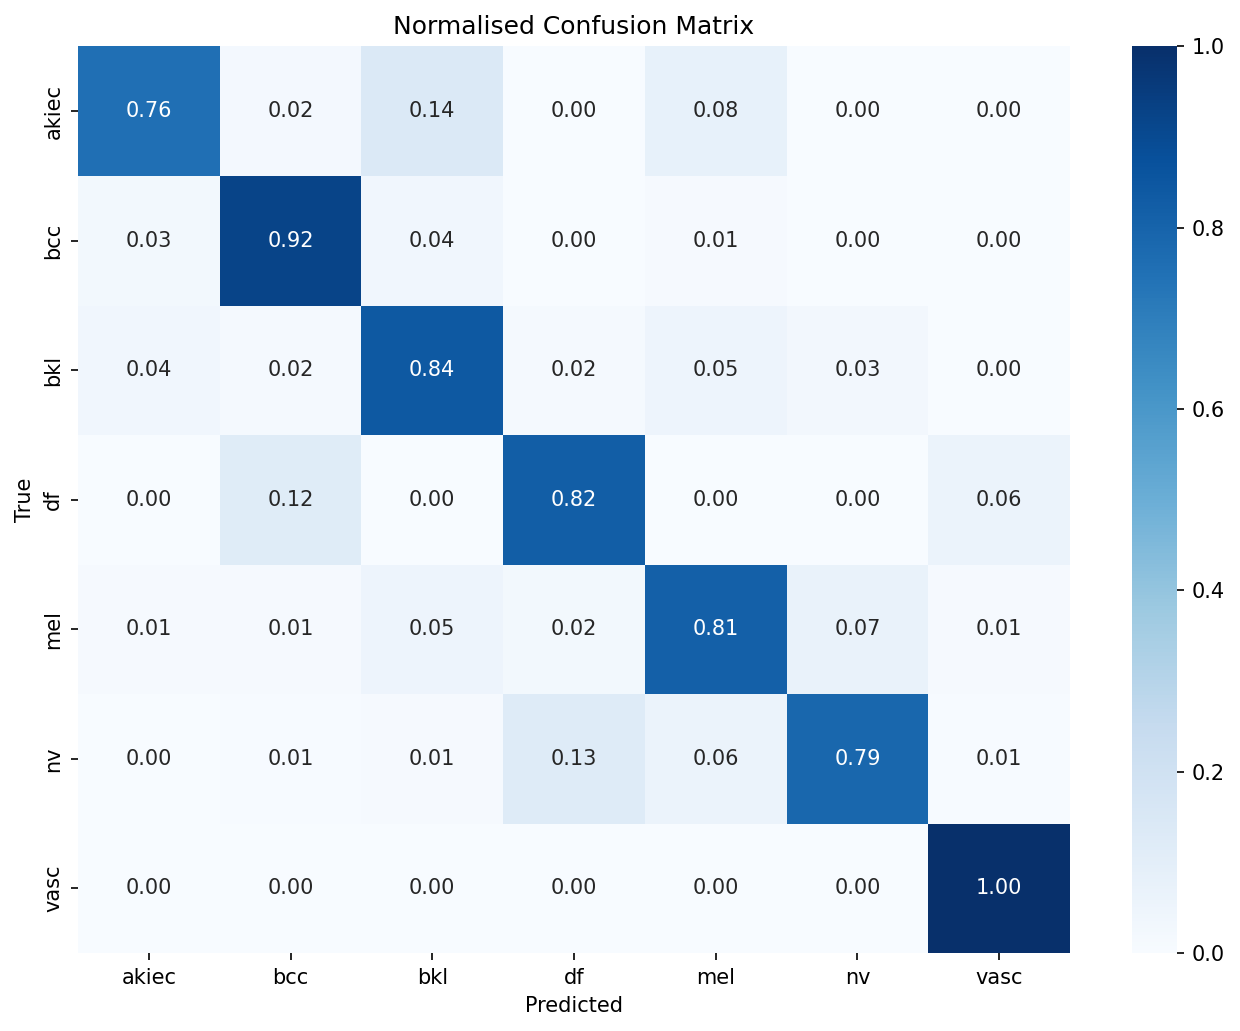

In [31]:
save_confusion_matrix(test_labels, test_preds, CLASS_NAMES, CONF_MAT_PATH)

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(CONF_MAT_PATH))
except Exception:
    print(f'Open manually: {CONF_MAT_PATH}')

## STEP 15 — Per-Class Accuracy Bar Chart

Bar chart saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\per_class_acc.png


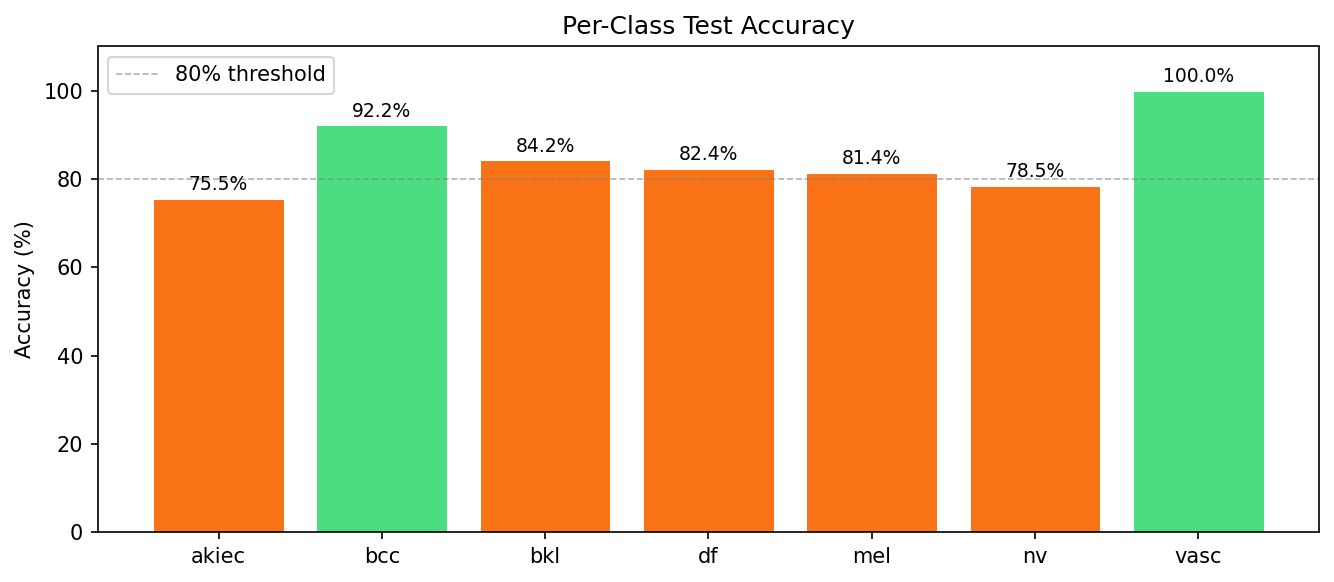


Per-class accuracy:
  akiec :  75.5%  ██████████████████████████████
  bcc   :  92.2%  ████████████████████████████████████
  bkl   :  84.2%  █████████████████████████████████
  df    :  82.4%  ████████████████████████████████
  mel   :  81.4%  ████████████████████████████████
  nv    :  78.5%  ███████████████████████████████
  vasc  : 100.0%  ████████████████████████████████████████


In [32]:
cm = confusion_matrix(test_labels, test_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#ef4444' if a < 0.7 else '#f97316' if a < 0.85 else '#4ade80'
          for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy')
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='80% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
bar_path = CONF_MAT_PATH.replace('confusion_matrix', 'per_class_acc')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'Bar chart saved → {bar_path}')

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(bar_path))
except Exception:
    pass

print('\nPer-class accuracy:')
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    bar = '█' * int(acc * 40)
    print(f'  {cls:6s}: {acc*100:5.1f}%  {bar}')

## STEP 16 — Summary

In [33]:
print('╔══════════════════════════════════════════════════════╗')
print('║      SKIN LESION CLASSIFIER v2 — FINAL SUMMARY       ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Backbone     : Swin-B (pretrained from SwinUNet v4) ║')
print(f'║  Head         : FPN + GAP + MLP                      ║')
print(f'║  Improvements : WeightedSampler + MixUp + 50ep P2    ║')
print(f'║  Dataset      : HAM10000 ({len(train_df)+len(val_df)+len(test_df)} images)              ║')
print(f'║  Split        : {len(train_df)} / {len(val_df)} / {len(test_df)} (train/val/test)  ║')
print(f'║  Test Loss    : {test_loss:.4f}                               ║')
print(f'║  Test Accuracy: {test_acc:.4f}  ({test_acc*100:.1f}%)                      ║')
print(f'║  Test Macro F1: {test_f1:.4f}                               ║')
print(f'║  Model saved  → skin_classifier_best.pth             ║')
print(f'║  Report saved → classification_report.txt            ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║      SKIN LESION CLASSIFIER v2 — FINAL SUMMARY       ║
╠══════════════════════════════════════════════════════╣
║  Backbone     : Swin-B (pretrained from SwinUNet v4) ║
║  Head         : FPN + GAP + MLP                      ║
║  Improvements : WeightedSampler + MixUp + 50ep P2    ║
║  Dataset      : HAM10000 (10015 images)              ║
║  Split        : 7010 / 1502 / 1503 (train/val/test)  ║
║  Test Loss    : 1.6900                               ║
║  Test Accuracy: 0.8044  (80.4%)                      ║
║  Test Macro F1: 0.7186                               ║
║  Model saved  → skin_classifier_best.pth             ║
║  Report saved → classification_report.txt            ║
╚══════════════════════════════════════════════════════╝


## STEP 17 — XAI Setup & Sample Collection

In [34]:
import cv2
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

# XAI_DIR is already defined in Step 4 and points to SAVE_DIR/xai_outputs
print(f'XAI output directory: {XAI_DIR}')

# Reload best model
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Model loaded for XAI. Best Val F1: {ckpt["best_val_f1"]:.4f}')

SAMPLES_PER_CLASS = 2

inv_normalize = __import__('torchvision').transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def tensor_to_rgb(tensor):
    img = inv_normalize(tensor.cpu()).clamp(0, 1)
    return img.permute(1, 2, 0).numpy().astype(np.float32)

xai_samples = {i: [] for i in range(NUM_CLASSES)}

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev = imgs.to(DEVICE)
        preds    = model(imgs_dev).argmax(dim=1).cpu()
        for img, lbl, pred in zip(imgs, labels, preds):
            c = lbl.item()
            if len(xai_samples[c]) < SAMPLES_PER_CLASS:
                xai_samples[c].append((img, c, pred.item()))
        if all(len(v) >= SAMPLES_PER_CLASS for v in xai_samples.values()):
            break

print(f'Collected {sum(len(v) for v in xai_samples.values())} samples for XAI.')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:6s}: {len(xai_samples[i])} sample(s)')

XAI output directory: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs
Model loaded for XAI. Best Val F1: 0.7171
Collected 14 samples for XAI.
  akiec : 2 sample(s)
  bcc   : 2 sample(s)
  bkl   : 2 sample(s)
  df    : 2 sample(s)
  mel   : 2 sample(s)
  nv    : 2 sample(s)
  vasc  : 2 sample(s)


## STEP 18 — Grad-CAM & Grad-CAM++

Running Grad-CAM...
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcam_akiec.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcam_bcc.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcam_bkl.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcam_df.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcam_mel.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcam_nv.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcam_vasc.png

Running Grad-CAM++...
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcampp_akiec.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcampp_bcc.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\gradcampp_bkl.png
  Saved: D:\MULTIMODAL CLASSIFICATION 3\outputs\

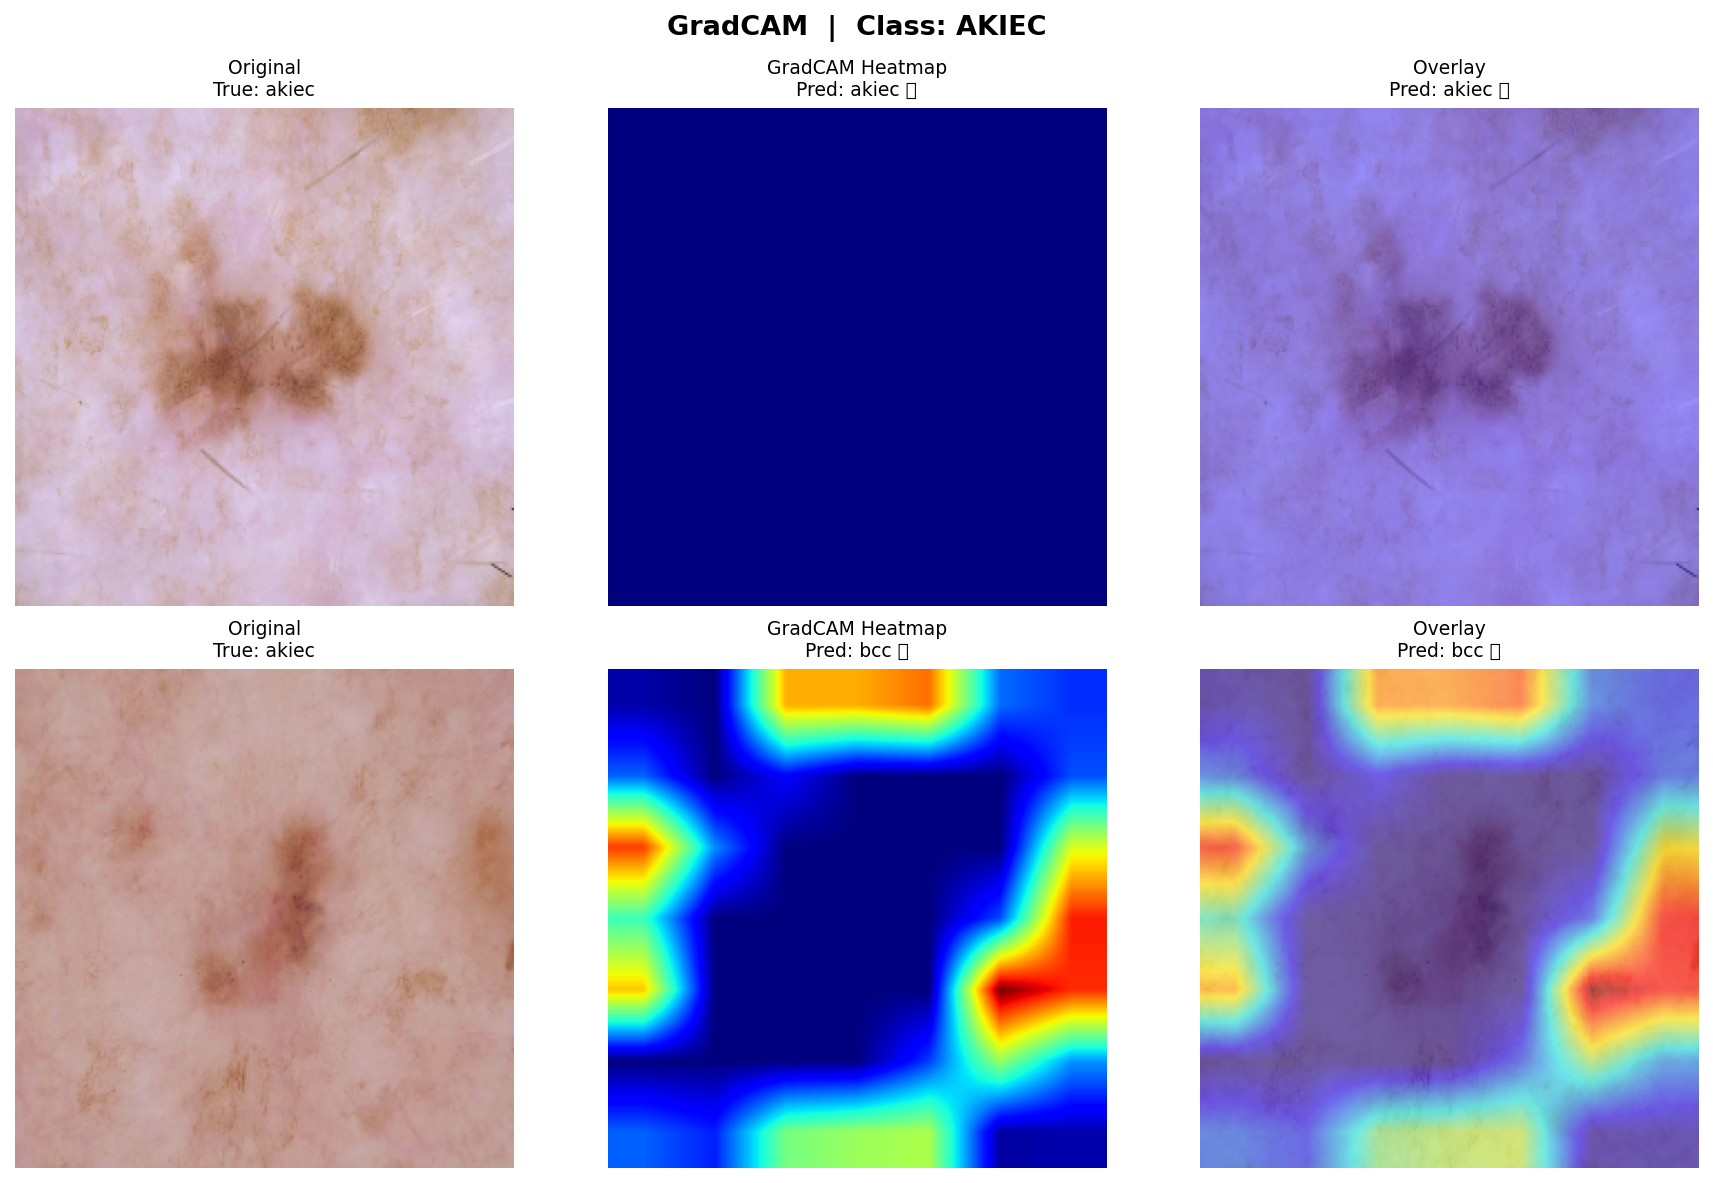

In [35]:
target_layers = [model.fpn.smooth_convs[-1][0]]

def run_gradcam(sample_dict, method_class, method_name, save_dir):
    cam_engine = method_class(model=model, target_layers=target_layers)
    for class_idx, samples in sample_dict.items():
        if not samples:
            continue
        cls_name  = CLASS_NAMES[class_idx]
        n         = len(samples)
        fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
        if n == 1:
            axes = [axes]
        fig.suptitle(f'{method_name}  |  Class: {cls_name.upper()}', fontsize=13, fontweight='bold')

        for row, (tensor, true_lbl, pred_lbl) in enumerate(samples):
            rgb_img       = tensor_to_rgb(tensor)
            input_t       = tensor.unsqueeze(0).to(DEVICE)
            targets       = [ClassifierOutputTarget(pred_lbl)]
            grayscale_cam = cam_engine(input_tensor=input_t, targets=targets)[0]
            cam_overlay   = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
            correct       = '✅' if true_lbl == pred_lbl else '❌'
            pred_name     = CLASS_NAMES[pred_lbl]

            axes[row][0].imshow(rgb_img)
            axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9)
            axes[row][0].axis('off')
            axes[row][1].imshow(grayscale_cam, cmap='jet')
            axes[row][1].set_title(f'{method_name} Heatmap\nPred: {pred_name} {correct}', fontsize=9)
            axes[row][1].axis('off')
            axes[row][2].imshow(cam_overlay)
            axes[row][2].set_title(f'Overlay\nPred: {pred_name} {correct}', fontsize=9)
            axes[row][2].axis('off')

        plt.tight_layout()
        save_path = os.path.join(save_dir, f'{method_name.lower().replace("++","pp")}_{cls_name}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  Saved: {save_path}')
    if hasattr(cam_engine, '__del__'):
        cam_engine.__del__()


print('Running Grad-CAM...')
run_gradcam(xai_samples, GradCAM,         'GradCAM',   XAI_DIR)
print('\nRunning Grad-CAM++...')
run_gradcam(xai_samples, GradCAMPlusPlus, 'GradCAM++', XAI_DIR)
print('\nGrad-CAM & Grad-CAM++ complete.')

try:
    from IPython.display import Image as IPImage, display
    p = os.path.join(XAI_DIR, f'gradcam_{CLASS_NAMES[0]}.png')
    if os.path.exists(p): display(IPImage(p))
except Exception:
    pass

## STEP 19 — Occlusion Sensitivity Maps

In [36]:
def occlusion_sensitivity(model, input_tensor, target_class, patch_size=28, stride=14, device=DEVICE):
    model.eval()
    C, H, W         = input_tensor.shape
    sensitivity_map = np.zeros((H, W), dtype=np.float32)
    count_map       = np.zeros((H, W), dtype=np.float32)

    with torch.no_grad():
        base_prob = F.softmax(model(input_tensor.unsqueeze(0).to(device)), dim=1)[0, target_class].item()

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = input_tensor.clone()
            occluded[:, y:y+patch_size, x:x+patch_size] = 0.5
            with torch.no_grad():
                prob = F.softmax(model(occluded.unsqueeze(0).to(device)), dim=1)[0, target_class].item()
            drop = base_prob - prob
            sensitivity_map[y:y+patch_size, x:x+patch_size] += drop
            count_map[y:y+patch_size, x:x+patch_size]       += 1

    sensitivity_map /= np.maximum(count_map, 1)
    s_min, s_max = sensitivity_map.min(), sensitivity_map.max()
    if s_max > s_min:
        sensitivity_map = (sensitivity_map - s_min) / (s_max - s_min)
    return sensitivity_map


print('Running Occlusion Sensitivity Maps (~2-4 min)...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue
    cls_name  = CLASS_NAMES[class_idx]
    n         = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'Occlusion Sensitivity  |  Class: {cls_name.upper()}', fontsize=13, fontweight='bold')

    for row, (tensor, true_lbl, pred_lbl) in enumerate(samples):
        rgb_img         = tensor_to_rgb(tensor)
        sens_map        = occlusion_sensitivity(model, tensor, pred_lbl, 28, 14, DEVICE)
        heatmap_colored = cv2.applyColorMap((sens_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
        overlay         = (0.5 * rgb_img + 0.5 * heatmap_rgb).clip(0, 1)
        correct         = '✅' if true_lbl == pred_lbl else '❌'
        pred_name       = CLASS_NAMES[pred_lbl]

        axes[row][0].imshow(rgb_img)
        axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9); axes[row][0].axis('off')
        axes[row][1].imshow(sens_map, cmap='hot')
        axes[row][1].set_title('Sensitivity Map\nBright = Important', fontsize=9); axes[row][1].axis('off')
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(f'Overlay\nPred: {pred_name} {correct}', fontsize=9); axes[row][2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'occlusion_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nOcclusion Sensitivity complete.')

Running Occlusion Sensitivity Maps (~2-4 min)...
  akiec: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\occlusion_akiec.png
  bcc: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\occlusion_bcc.png
  bkl: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\occlusion_bkl.png
  df: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\occlusion_df.png
  mel: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\occlusion_mel.png
  nv: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\occlusion_nv.png
  vasc: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\occlusion_vasc.png

Occlusion Sensitivity complete.


## STEP 20 — LIME Explanations

In [37]:
def lime_predict_fn(images_np):
    mean  = torch.tensor([0.485, 0.456, 0.406])
    std   = torch.tensor([0.229, 0.224, 0.225])
    batch = []
    for img in images_np:
        t = torch.from_numpy(img).float() / 255.0
        t = (t - mean) / std
        batch.append(t.permute(2, 0, 1))
    batch = torch.stack(batch).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(batch), dim=1)
    return probs.cpu().numpy()


explainer = lime_image.LimeImageExplainer()
print('Running LIME explanations (~3-5 min)...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue
    cls_name  = CLASS_NAMES[class_idx]
    n         = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'LIME Explanation  |  Class: {cls_name.upper()}', fontsize=13, fontweight='bold')

    for row, (tensor, true_lbl, pred_lbl) in enumerate(samples):
        rgb_img  = tensor_to_rgb(tensor)
        rgb_uint = (rgb_img * 255).astype(np.uint8)

        explanation = explainer.explain_instance(
            rgb_uint, lime_predict_fn,
            top_labels=NUM_CLASSES,    # ← explains ALL 7 classes — prevents KeyError
            hide_color=0, num_samples=1000, random_seed=42
        )

        # Safety fallback
        available_labels = list(explanation.local_exp.keys())
        label_to_use     = pred_lbl if pred_lbl in available_labels else available_labels[0]
        if label_to_use != pred_lbl:
            print(f'    ⚠️  pred_lbl {pred_lbl} not found, using {label_to_use}')

        temp_img, mask = explanation.get_image_and_mask(
            label_to_use, positive_only=False, num_features=8, hide_rest=False
        )
        temp_pos, mask_pos = explanation.get_image_and_mask(
            label_to_use, positive_only=True, num_features=8, hide_rest=True
        )

        correct   = '✅' if true_lbl == pred_lbl else '❌'
        pred_name = CLASS_NAMES[pred_lbl]

        axes[row][0].imshow(rgb_img)
        axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9); axes[row][0].axis('off')
        axes[row][1].imshow(mark_boundaries(temp_img / 255.0, mask))
        axes[row][1].set_title(f'LIME: Green=For / Red=Against\nPred: {pred_name} {correct}', fontsize=9); axes[row][1].axis('off')
        axes[row][2].imshow(mark_boundaries(temp_pos / 255.0, mask_pos))
        axes[row][2].set_title(f'LIME: Positive Evidence Only\nPred: {pred_name} {correct}', fontsize=9); axes[row][2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'lime_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nLIME complete.')

Running LIME explanations (~3-5 min)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  akiec: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\lime_akiec.png


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  nv: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\lime_nv.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  vasc: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\lime_vasc.png

LIME complete.


## STEP 21 — XAI Summary Grid (All 4 Methods Side by Side)

Generating XAI Summary Grids (1 image per class, all 4 methods)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  akiec: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\xai_summary_akiec.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  bcc: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\xai_summary_bcc.png


...

  mel: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\xai_summary_mel.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  nv: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\xai_summary_nv.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  vasc: saved → D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs\xai_summary_vasc.png

All XAI Summary Grids saved.


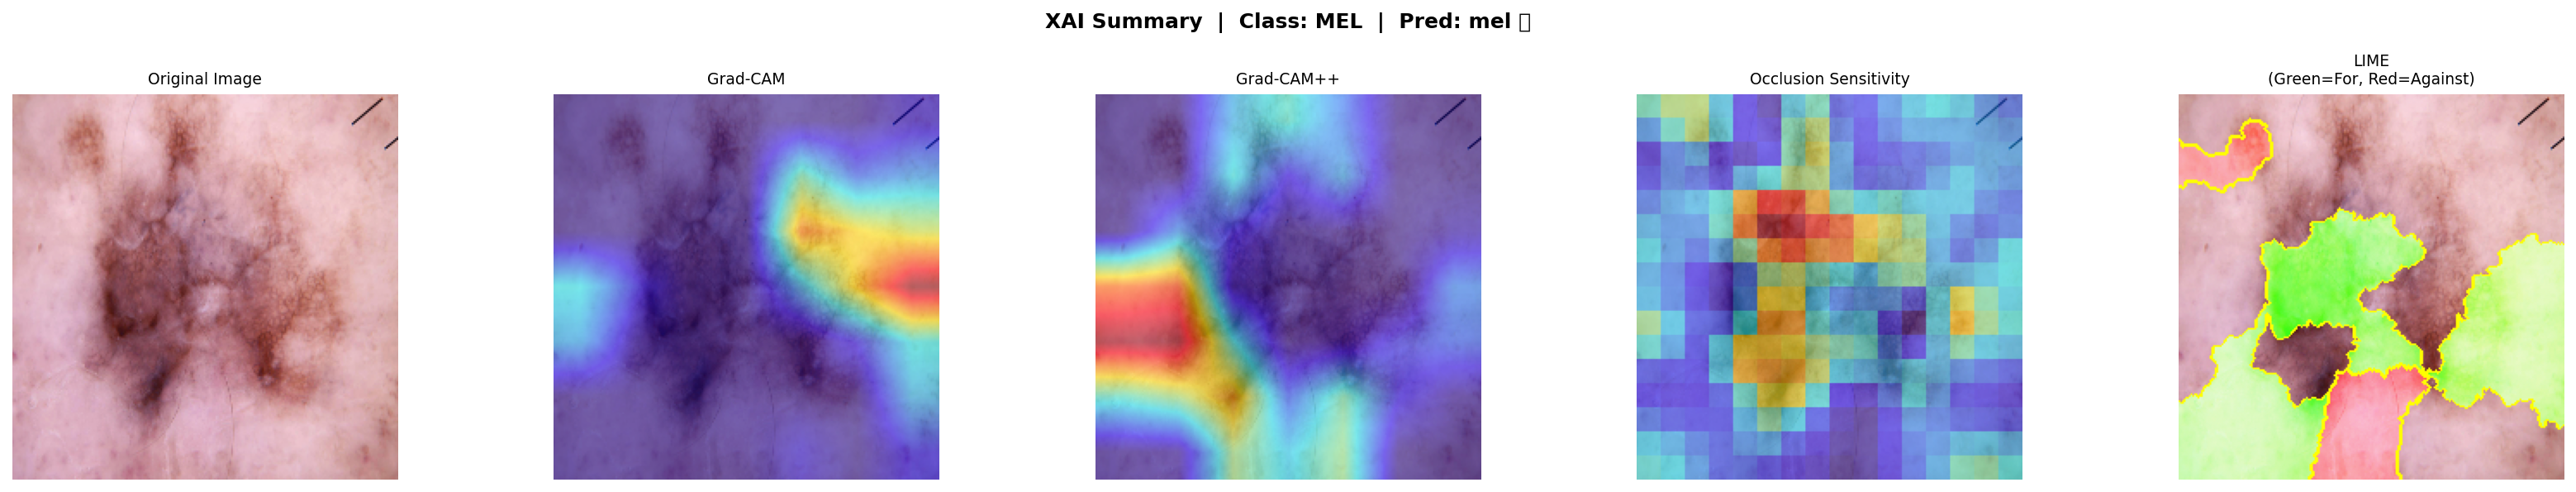


  XAI PIPELINE COMPLETE
  All outputs saved to: D:\MULTIMODAL CLASSIFICATION 3\outputs\classifier_v2\xai_outputs
  Files generated:
    gradcam_akiec.png
    gradcam_bcc.png
    gradcam_bkl.png
    gradcam_df.png
    gradcam_mel.png
    gradcam_nv.png
    gradcam_vasc.png
    gradcampp_akiec.png
    gradcampp_bcc.png
    gradcampp_bkl.png
    gradcampp_df.png
    gradcampp_mel.png
    gradcampp_nv.png
    gradcampp_vasc.png
    lime_akiec.png
    lime_bcc.png
    lime_bkl.png
    lime_df.png
    lime_mel.png
    lime_nv.png
    lime_vasc.png
    occlusion_akiec.png
    occlusion_bcc.png
    occlusion_bkl.png
    occlusion_df.png
    occlusion_mel.png
    occlusion_nv.png
    occlusion_vasc.png
    xai_summary_akiec.png
    xai_summary_bcc.png
    xai_summary_bkl.png
    xai_summary_df.png
    xai_summary_mel.png
    xai_summary_nv.png
    xai_summary_vasc.png


In [38]:
print('Generating XAI Summary Grids (1 image per class, all 4 methods)...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue

    cls_name              = CLASS_NAMES[class_idx]
    tensor, true_lbl, pred_lbl = samples[0]
    rgb_img   = tensor_to_rgb(tensor)
    input_t   = tensor.unsqueeze(0).to(DEVICE)
    rgb_uint  = (rgb_img * 255).astype(np.uint8)
    correct   = '✅' if true_lbl == pred_lbl else '❌'
    pred_name = CLASS_NAMES[pred_lbl]
    targets   = [ClassifierOutputTarget(pred_lbl)]

    # 1. Grad-CAM
    with GradCAM(model=model, target_layers=target_layers) as cam:
        gcam_map     = cam(input_tensor=input_t, targets=targets)[0]
        gcam_overlay = show_cam_on_image(rgb_img, gcam_map, use_rgb=True)

    # 2. Grad-CAM++
    with GradCAMPlusPlus(model=model, target_layers=target_layers) as cam:
        gcampp_map     = cam(input_tensor=input_t, targets=targets)[0]
        gcampp_overlay = show_cam_on_image(rgb_img, gcampp_map, use_rgb=True)

    # 3. Occlusion
    sens_map        = occlusion_sensitivity(model, tensor, pred_lbl, 28, 14, DEVICE)
    heatmap_colored = cv2.applyColorMap((sens_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
    occ_overlay     = (0.5 * rgb_img +
                       0.5 * cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0).clip(0, 1)

    # 4. LIME
    lime_exp = explainer.explain_instance(
        rgb_uint, lime_predict_fn,
        top_labels=NUM_CLASSES,    # ← prevents KeyError
        hide_color=0, num_samples=1000, random_seed=42
    )
    available_labels = list(lime_exp.local_exp.keys())
    label_to_use     = pred_lbl if pred_lbl in available_labels else available_labels[0]
    lime_img, lime_mask = lime_exp.get_image_and_mask(
        label_to_use, positive_only=False, num_features=8, hide_rest=False
    )
    lime_overlay = mark_boundaries(lime_img / 255.0, lime_mask)

    # Plot 1×5 grid
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(
        f'XAI Summary  |  Class: {cls_name.upper()}  |  Pred: {pred_name} {correct}',
        fontsize=12, fontweight='bold'
    )
    for ax, (img, title) in zip(axes, [
        (rgb_img,        'Original Image'),
        (gcam_overlay,   'Grad-CAM'),
        (gcampp_overlay, 'Grad-CAM++'),
        (occ_overlay,    'Occlusion Sensitivity'),
        (lime_overlay,   'LIME\n(Green=For, Red=Against)'),
    ]):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'xai_summary_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nAll XAI Summary Grids saved.')

try:
    from IPython.display import Image as IPImage, display
    ex_path = os.path.join(XAI_DIR, f'xai_summary_{CLASS_NAMES[4]}.png')
    if os.path.exists(ex_path):
        display(IPImage(ex_path))
except Exception:
    pass

print('\n' + '=' * 55)
print('  XAI PIPELINE COMPLETE')
print('=' * 55)
print(f'  All outputs saved to: {XAI_DIR}')
print('  Files generated:')
for f in sorted(os.listdir(XAI_DIR)):
    print(f'    {f}')